In [34]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
dados = fetch_california_housing(as_frame=True)
df = dados.frame

In [2]:
# 1 -> MedInc, HouseAge, AveRooms, Population, AveOccup, Latitude, Longitude

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
total_linhas = len(df)
print('total linhas -> ', total_linhas)

total linhas ->  20640


In [11]:
print("aributo y alvo > ", dados.target_names)

aributo y alvo >  ['MedHouseVal']


In [15]:
#métodos mais eficientes são .isna() (ou .isna()) combinados com funções de agregação como .sum() e .any().
# valores ausentes por coluna
print(' valores ausentes por coluna')
df.isna().sum()


 valores ausentes por coluna


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [17]:
print('apenas colunas com nan')
nulos = df.isna().sum()
print(nulos[nulos > 0])

apenas colunas com nan
Series([], dtype: int64)


In [20]:
# Retorna True se houver pelo menos um NaN no DataFrame inteiro
tem_nulos = df.isna().any().any()
print("Existe algum valor ausente?", tem_nulos)

# Contagem total de NaNs somando todas as colunas
total_nulos = df.isna().sum().sum()
print("Total absoluto de NaNs no dataset:", total_nulos)

Existe algum valor ausente? False
Total absoluto de NaNs no dataset: 0


In [ ]:
# não é estritamente necessário normalizar ou padronizar os dados para que o modelo funcione ou para obter boas predições.
# para verificar se precisa de normalização podemos verificar difeenças de escalas (1 a 1000000) ou presença de outliers
df.describe()

# MedInc (Renda): varia entre ~0.5 e 15.
# HouseAge (Idade da casa): varia entre 1 e 52 anos.
# Population (População do bloco): varia entre 3 e mais de 35.000 pessoas.
# AveRooms / AveOccup: possuem outliers pesados (ex: blocos com média de mais de 1000 ocupantes por residência).

#por isso é importante normalizar

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
#avaliar critérios de correlação linear
# Calcula a correlação de todas as variáveis com o alvo 'MedHouseVal'
correlacoes = df.corr()['MedHouseVal'].drop('MedHouseVal')
print(correlacoes.abs().sort_values(ascending=False))
#Critério: O atributo com o maior valor absoluto de correlação é o candidato mais forte para uma regressão linear simples.

MedInc        0.688075
AveRooms      0.151948
Latitude      0.144160
HouseAge      0.105623
AveBedrms     0.046701
Longitude     0.045967
Population    0.024650
AveOccup      0.023737
Name: MedHouseVal, dtype: float64


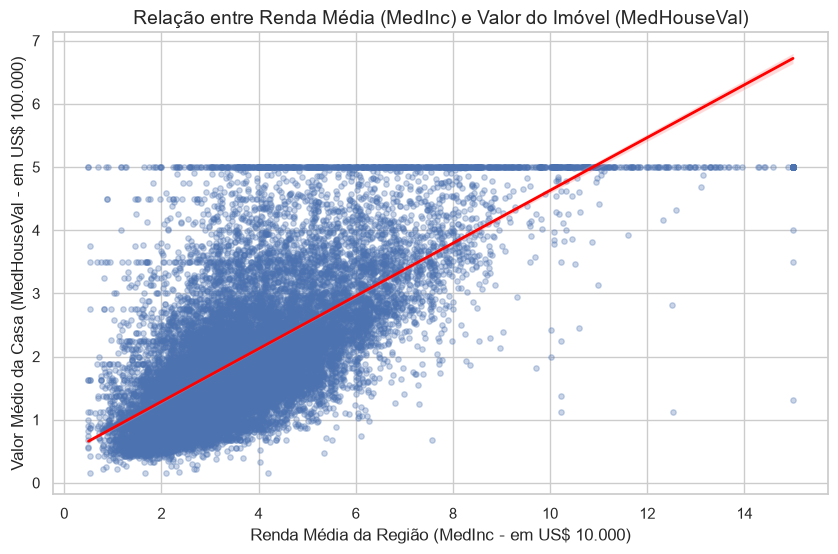

In [28]:
# 1. Configurar o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Criar o gráfico de dispersão com a linha de regressão
sns.regplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    scatter_kws={"alpha": 0.3, "s": 15},  # Transparência e tamanho dos pontos
    line_kws={"color": "red", "linewidth": 2},  # Reta de regressão em vermelho
)

# 3. Adicionar títulos e rótulos aos eixos
plt.title("Relação entre Renda Média (MedInc) e Valor do Imóvel (MedHouseVal)", fontsize=14)
plt.xlabel("Renda Média da Região (MedInc - em US$ 10.000)", fontsize=12)
plt.ylabel("Valor Médio da Casa (MedHouseVal - em US$ 100.000)", fontsize=12)

plt.show()

In [31]:
from sklearn.model_selection import train_test_split
# Separando 80% para treino e 20% para teste
X = df[["MedInc"]] # precisa ser uma matriz
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

'''
Avaliar o modelo com os mesmos dados usados para ajustá-lo é uma má prática fundamental em Machine Learning pelos seguintes motivos:Superajuste (Overfitting): O modelo pode simplesmente "decorar" os padrões e ruídos específicos do conjunto de treino em vez de aprender a relação geral entre as variáveis.
Falsa Ilusão de Desempenho: 
Testar no treino resulta em métricas otimistas e irrealistas (como um $R^2$ muito alto ou erro próximo de zero). No entanto, o modelo falhará ao receber dados novos do mundo real.
'''


Treino: 16512 amostras
Teste:  4128 amostras


'\nAvaliar o modelo com os mesmos dados usados para ajustá-lo é uma má prática fundamental em Machine Learning pelos seguintes motivos:Superajuste (Overfitting): O modelo pode simplesmente "decorar" os padrões e ruídos específicos do conjunto de treino em vez de aprender a relação geral entre as variáveis.\nFalsa Ilusão de Desempenho: \nTestar no treino resulta em métricas otimistas e irrealistas (como um $R^2$ muito alto ou erro próximo de zero). No entanto, o modelo falhará ao receber dados novos do mundo real.\n'

In [35]:
# Treinamento
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.42]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['MedInc']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4446
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
